# Wake post-processing (wake1)

Binary Tecplot (.plt) -> Zarr -> slices, line probes, and plots.

Data: inputs/flood-log-7/


## Setup - paths and imports


In [64]:
from pathlib import Path

ROOT = Path('.').resolve()
DATA_F_log = ROOT / 'inputs' / 'flood-log-7'
DATA_E_log = ROOT / 'inputs' / 'ebb-log-7'
PLT_F_log = DATA_F_log / 'Result015000-avg.plt'
PLT_E_log = DATA_E_log / 'Result001800-avg.plt'
ZARR_F_log = DATA_F_log / 'Result015000-avg.zarr'
ZARR_E_log = DATA_E_log / 'Result001800-avg.zarr'
OUT = ROOT / 'outputs'
OUT.mkdir(exist_ok=True)

import sys
sys.path.insert(0, str(ROOT / 'tools'))

# Pick up edits to tools/*.py without restarting the kernel
%load_ext autoreload
%autoreload 2

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from tecplot_binary import TecplotBinaryDataset
from wake_store import WakeStore, node_to_cell_2d

# Aliases for flood case (ebb uses *_E_log paths below)
PLT, ZARR = PLT_F_log, ZARR_F_log

print('ROOT:', ROOT)
print('Flood PLT:', PLT_F_log.is_file(), ' Zarr:', ZARR_F_log.is_dir())
print('Ebb PLT:', PLT_E_log.is_file(), ' Zarr:', ZARR_E_log.is_dir())


The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload
ROOT: C:\Users\hseyyedzadeh\Box\Projects\Verdant\data-analysis\cfd-wake-analysis
Flood PLT: True  Zarr: True
Ebb PLT: True  Zarr: True


## 1 - Install dependencies (run once)


In [65]:
#!python -m pip install -r requirements.txt

## 2 - Ingest binary to Zarr (run once per case)


In [66]:
#import subprocess
#subprocess.run(
#    ['python', 'scripts/ingest_plt_to_zarr.py', str(PLT), '-o', str(ZARR), '--overwrite'],
#    check=True,
#)

Optional: subset ingest (faster)


In [67]:
# subprocess.run(
#     ['python', 'scripts/ingest_plt_to_zarr.py', str(PLT), '-o', str(ZARR),
#      '--vars', 'X', 'Y', 'Z', 'U', 'V', 'W', 'K', '--overwrite'],
#     check=True,
# )

## 3 - Inspect Tecplot binary metadata


In [68]:
ds = TecplotBinaryDataset(PLT, read_data=False)
print(ds.summary())

file: C:\Users\hseyyedzadeh\Box\Projects\Verdant\data-analysis\cfd-wake-analysis\inputs\flood-log-7\Result015000-avg.plt
title: Averaging
zone: Block 1
ijk: I=1325, J=73, K=1325 (128,160,625 nodes)
variables (14):
  X     node  shape=(1325, 73, 1325)
  Y     node  shape=(1325, 73, 1325)
  Z     node  shape=(1325, 73, 1325)
  U     cell  shape=(1324, 72, 1324)
  V     cell  shape=(1324, 72, 1324)
  W     cell  shape=(1324, 72, 1324)
  uu    cell  shape=(1324, 72, 1324)
  vv    cell  shape=(1324, 72, 1324)
  ww    cell  shape=(1324, 72, 1324)
  uv    cell  shape=(1324, 72, 1324)
  vw    cell  shape=(1324, 72, 1324)
  uw    cell  shape=(1324, 72, 1324)
  K     cell  shape=(1324, 72, 1324)
  Nv    cell  shape=(1324, 72, 1324)


## 4 - Inspect Zarr store


In [69]:
store = WakeStore.open(ZARR)
print(store.summary())

store: C:\Users\hseyyedzadeh\Box\Projects\Verdant\data-analysis\cfd-wake-analysis\inputs\flood-log-7\Result015000-avg.zarr
title: Averaging
source: C:\Users\hseyyedzadeh\Box\Projects\Verdant\data-analysis\cfd-wake-analysis\inputs\flood-log-7\Result015000-avg.plt
ijk: I=1325, J=73, K=1325
variables:
  X     node  shape=(1325, 73, 1325)  chunks=(128, 73, 128)
  Y     node  shape=(1325, 73, 1325)  chunks=(128, 73, 128)
  Z     node  shape=(1325, 73, 1325)  chunks=(128, 73, 128)
  U     cell  shape=(1324, 72, 1324)  chunks=(128, 72, 128)
  V     cell  shape=(1324, 72, 1324)  chunks=(128, 72, 128)
  W     cell  shape=(1324, 72, 1324)  chunks=(128, 72, 128)
  uu    cell  shape=(1324, 72, 1324)  chunks=(128, 72, 128)
  vv    cell  shape=(1324, 72, 1324)  chunks=(128, 72, 128)
  ww    cell  shape=(1324, 72, 1324)  chunks=(128, 72, 128)
  uv    cell  shape=(1324, 72, 1324)  chunks=(128, 72, 128)
  vw    cell  shape=(1324, 72, 1324)  chunks=(128, 72, 128)
  uw    cell  shape=(1324, 72, 1324)  ch

In [70]:
import subprocess
subprocess.run(['python', 'scripts/wake_postprocess.py', str(ZARR), 'info'], check=True)

CompletedProcess(args=['python', 'scripts/wake_postprocess.py', 'C:\\Users\\hseyyedzadeh\\Box\\Projects\\Verdant\\data-analysis\\cfd-wake-analysis\\inputs\\flood-log-7\\Result015000-avg.zarr', 'info'], returncode=0)

## 5 - Map physical Y to grid index J (for Y = 0.65)


In [71]:
TARGET_Y = 0.65

Y = store.read('Y')
y_at_j = Y.mean(axis=(0, 2))
j_idx = int(np.argmin(np.abs(y_at_j - TARGET_Y)))

print(f'Target Y = {TARGET_Y}')
print(f'J index = {j_idx},  Y on plane ~ {y_at_j[j_idx]:.4f}')
print(f'Y range on grid: [{y_at_j.min():.4f}, {y_at_j.max():.4f}]')

Target Y = 0.65
J index = 63,  Y on plane ~ 0.6613
Y range on grid: [-0.2801, 0.9813]


## 6 - Contour of W on vertical plane (fixed normal y, spanwise x, streamwise z)

Coordinates (normalized): **x** spanwise, **y** normal, **z** streamwise.  
Plane: constant **y** → Tecplot `XZ` slice (axes: **x**, **z**).


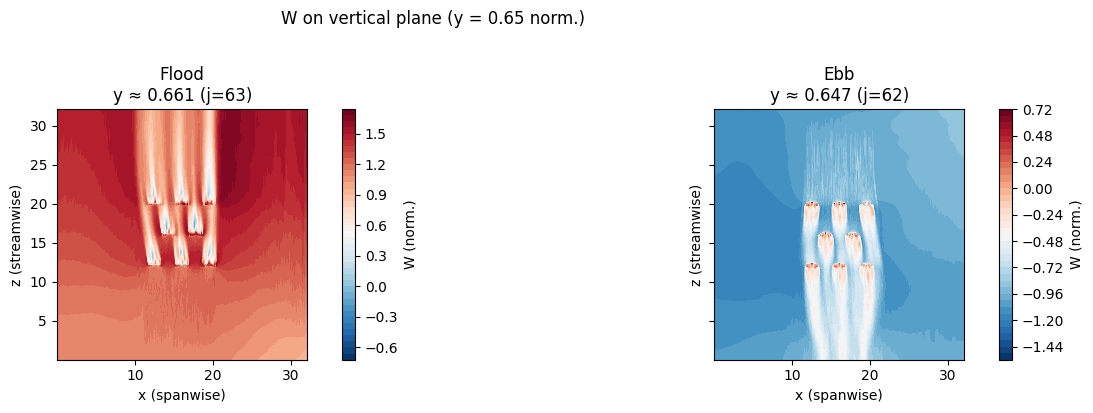

In [72]:
def contour_w_xz(store, j_idx, y_norm, *, label, ax, levels=40):
    """Vertical plane: constant y (normal); plot W vs x (spanwise) and z (streamwise)."""
    sl = store.slice_plane('XZ', j_idx, variables=['X', 'Z', 'W'])
    x_span, z_str, w = sl.arrays['X'], sl.arrays['Z'], sl.arrays['W']
    xc = node_to_cell_2d(x_span)
    zc = node_to_cell_2d(z_str)
    assert xc.shape == w.shape == zc.shape
    cf = ax.contourf(xc, zc, w, levels=levels, cmap='RdBu_r')
    plt.colorbar(cf, ax=ax, label='W (norm.)')
    ax.set_xlabel('x (spanwise)')
    ax.set_ylabel('z (streamwise)')
    ax.set_title(f'{label}\ny ≈ {y_norm:.3f} (j={j_idx})')
    ax.set_aspect('equal')
    return cf


TARGET_Y = 0.65  # normalized normal coordinate

# --- Flood ---
store_flood = WakeStore.open(ZARR_F_log)
y_flood = store_flood.read('Y').mean(axis=(0, 2))
j_flood = int(np.argmin(np.abs(y_flood - TARGET_Y)))

# --- Ebb (ingest PLT_E_log → ZARR_E_log first if missing) ---
if not ZARR_E_log.is_dir():
    import subprocess
    subprocess.run(
        ['python', 'scripts/ingest_plt_to_zarr.py', str(PLT_E_log), '-o', str(ZARR_E_log), '--overwrite'],
        check=True,
    )
store_ebb = WakeStore.open(ZARR_E_log)
y_ebb = store_ebb.read('Y').mean(axis=(0, 2))
j_ebb = int(np.argmin(np.abs(y_ebb - TARGET_Y)))

fig, axes = plt.subplots(1, 2, figsize=(14, 4), sharex=True, sharey=True)
contour_w_xz(store_flood, j_flood, y_flood[j_flood], label='Flood', ax=axes[0])
contour_w_xz(store_ebb, j_ebb, y_ebb[j_ebb], label='Ebb', ax=axes[1])
fig.suptitle(f'W on vertical plane (y = {TARGET_Y} norm.)', y=1.02)
plt.tight_layout()
plt.show()

## 7 - Line probes at spanwise x (fixed y = hub height)

Legacy names like `x11964` mean **x = 11.964 H** (digits after `x` ÷ 1000). Each line runs along **streamwise** (Tecplot `K` / field `Z`) at fixed **spanwise** `I` and **normal** `J`.

Wake deficit: `wake_deficit = 1 - |W|` (streamwise speed **|W|**, freestream = 1). Column `abs_W` is also stored. Extracted for **flood** and **ebb**.

In [83]:
# Spanwise x/H targets (name x11964 -> 11.964). Matches legacy ./line/x*.csv locations.
LINE_X_LOCATIONS = {
    'x11964': 11.964,
    'x12589': 12.589,
    'x13214': 13.214,
    'x13708': 13.708,
    'x14333': 14.333,
    'x14958': 14.958,
    'x15443': 15.443,
    'x16068': 16.068,
    'x16693': 16.693,
    'x17178': 17.178,
    'x17803': 17.803,
    'x18428': 18.428,
    'x18914': 18.914,
    'x19539': 19.539,
    'x20164': 20.164,
}

LINE_VARS = ['X', 'Y', 'Z', 'U', 'V', 'W', 'K']


def line_at_x_norm(store, x_target, j_idx, variables=LINE_VARS):
    """1D probe along streamwise K at fixed spanwise I and normal J."""
    x_at_i = store.read('X')[:, j_idx, :].mean(axis=1)
    i_idx = int(np.argmin(np.abs(x_at_i - x_target)))
    # W, K are cell-centered (len K-1); X,Y,Z are nodes (len K) — align to cell centers.
    data = store.line_probe(
        'K', fixed={'I': i_idx, 'J': j_idx}, variables=list(variables), align_to='cell'
    )
    df = pd.DataFrame({k: v for k, v in data.items() if k != 'index'})
    df['abs_W'] = np.abs(df['W'])
    df['wake_deficit'] = 1.0 - df['abs_W']
    return df, i_idx, float(x_at_i[i_idx])


import subprocess

if not ZARR_E_log.is_dir():
    subprocess.run(
        ['python', 'scripts/ingest_plt_to_zarr.py', str(PLT_E_log), '-o', str(ZARR_E_log), '--overwrite'],
        check=True,
    )

store_flood = WakeStore.open(ZARR_F_log)
y_flood = store_flood.read('Y').mean(axis=(0, 2))
j_flood = int(np.argmin(np.abs(y_flood - TARGET_Y)))

store_ebb = WakeStore.open(ZARR_E_log)
y_ebb = store_ebb.read('Y').mean(axis=(0, 2))
j_ebb = int(np.argmin(np.abs(y_ebb - TARGET_Y)))
print(f'Flood J={j_flood} (y~{y_flood[j_flood]:.4f}), Ebb J={j_ebb} (y~{y_ebb[j_ebb]:.4f})')


def extract_line_dfs(store, j_idx, case_label):
    out = {}
    for name, x_h in LINE_X_LOCATIONS.items():
        df, i_idx, x_snap = line_at_x_norm(store, x_h, j_idx)
        out[name] = df
        print(f'[{case_label}] {name}: x/H={x_h:.3f}, I={i_idx}, grid x={x_snap:.4f}, n={len(df)}')
    return out


line_dfs_flood = extract_line_dfs(store_flood, j_flood, 'flood')
line_dfs_ebb = extract_line_dfs(store_ebb, j_ebb, 'ebb')
line_dfs = line_dfs_flood  # alias for flood-only snippets

# Aliases for cells copied from wake.ipynb (flood)
x11964, x12589, x13214, x13708, x14333 = (
    line_dfs_flood['x11964'],
    line_dfs_flood['x12589'],
    line_dfs_flood['x13214'],
    line_dfs_flood['x13708'],
    line_dfs_flood['x14333'],
)
x14958, x15443, x16068, x16693, x17178 = (
    line_dfs_flood['x14958'],
    line_dfs_flood['x15443'],
    line_dfs_flood['x16068'],
    line_dfs_flood['x16693'],
    line_dfs_flood['x17178'],
)
x17803, x18428, x18914, x19539, x20164 = (
    line_dfs_flood['x17803'],
    line_dfs_flood['x18428'],
    line_dfs_flood['x18914'],
    line_dfs_flood['x19539'],
    line_dfs_flood['x20164'],
)

Flood J=63 (y~0.6613), Ebb J=62 (y~0.6465)
[flood] x11964: x/H=11.964, I=393, grid x=11.9590, n=1324
[flood] x12589: x/H=12.589, I=434, grid x=12.5855, n=1324
[flood] x13214: x/H=13.214, I=475, grid x=13.2117, n=1324
[flood] x13708: x/H=13.708, I=507, grid x=13.7005, n=1324
[flood] x14333: x/H=14.333, I=548, grid x=14.3267, n=1324
[flood] x14958: x/H=14.958, I=589, grid x=14.9529, n=1324
[flood] x15443: x/H=15.443, I=621, grid x=15.4417, n=1324
[flood] x16068: x/H=16.068, I=662, grid x=16.0679, n=1324
[flood] x16693: x/H=16.693, I=703, grid x=16.6941, n=1324
[flood] x17178: x/H=17.178, I=735, grid x=17.1829, n=1324
[flood] x17803: x/H=17.803, I=776, grid x=17.8091, n=1324
[flood] x18428: x/H=18.428, I=817, grid x=18.4353, n=1324
[flood] x18914: x/H=18.914, I=848, grid x=18.9088, n=1324
[flood] x19539: x/H=19.539, I=889, grid x=19.5351, n=1324
[flood] x20164: x/H=20.164, I=930, grid x=20.1615, n=1324
[ebb] x11964: x/H=11.964, I=931, grid x=11.9590, n=1324
[ebb] x12589: x/H=12.589, I=890

### Streamwise velocity

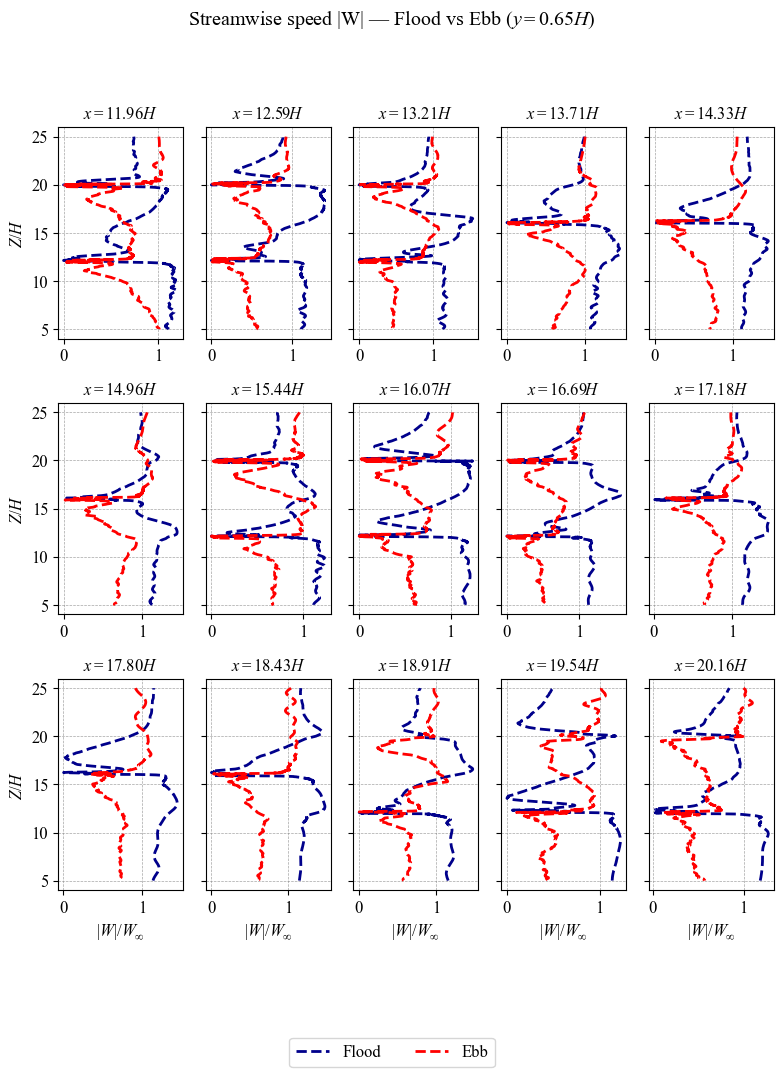

In [93]:
# Requires section 7 extraction cell above (line_dfs_flood, line_dfs_ebb).
assert line_dfs_flood and line_dfs_ebb, 'Run the extraction cell above first (section 7).'

plt.style.use('default')

# Subplot titles (rounded labels from wake.ipynb)
LINE_X_TITLES = {
    'x11964': '11.96',
    'x12589': '12.59',
    'x13214': '13.21',
    'x13708': '13.71',
    'x14333': '14.33',
    'x14958': '14.96',
    'x15443': '15.44',
    'x16068': '16.07',
    'x16693': '16.69',
    'x17178': '17.18',
    'x17803': '17.80',
    'x18428': '18.43',
    'x18914': '18.91',
    'x19539': '19.54',
    'x20164': '20.16',
}

Z_MIN, Z_MAX = 5.0, 25.0  # streamwise extent for plots (normalized Z/H)

PLOT_RC = {
    'font.size': 12,
    'font.family': 'Times New Roman',
    'axes.labelsize': 12,
    'axes.titlesize': 12,
    'legend.fontsize': 12,
    'xtick.labelsize': 12,
    'ytick.labelsize': 12,
    'mathtext.fontset': 'custom',
    'mathtext.rm': 'Times New Roman',
    'mathtext.it': 'Times New Roman:italic',
    'mathtext.bf': 'Times New Roman:bold',
    'mathtext.default': 'it',
}


def plot_flood_ebb_panels(line_dfs_flood, line_dfs_ebb, *, value_col, xlabel, suptitle):
    """Overlay flood (blue) and ebb (red) on the same 3x5 panels."""
    with plt.rc_context(PLOT_RC):
        fig, axs = plt.subplots(3, 5, figsize=(8, 10))
        for ax, name in zip(axs.flatten(), LINE_X_TITLES):
            df_f = line_dfs_flood[name]
            df_e = line_dfs_ebb[name]
            mask_f = (df_f['Z'] >= Z_MIN) & (df_f['Z'] <= Z_MAX)
            mask_e = (df_e['Z'] >= Z_MIN) & (df_e['Z'] <= Z_MAX)
            ax.plot(
                df_f.loc[mask_f, value_col],
                df_f.loc[mask_f, 'Z'],
                linestyle='--',
                linewidth=2,
                color='darkblue',
                label='Flood',
            )
            ax.plot(
                df_e.loc[mask_e, value_col],
                df_e.loc[mask_e, 'Z'],
                linestyle='--',
                linewidth=2,
                color='red',
                label='Ebb',
            )
            ax.set_title(f'$x={LINE_X_TITLES[name]}H$')
            ax.grid(True, color='gray', linestyle='--', linewidth=0.5, alpha=0.7)
        axs[0, 0].set_ylabel('$Z/H$')
        axs[1, 0].set_ylabel('$Z/H$')
        axs[2, 0].set_ylabel('$Z/H$')
        for ax in axs[:, 1:].flatten():
            ax.tick_params(axis='y', labelleft=False)
        for ax in axs[2, :]:
            ax.set_xlabel(xlabel)
        fig.suptitle(suptitle, y=1.02)
        fig.legend(
            *axs[0, 0].get_legend_handles_labels(),
            loc='upper center',
            bbox_to_anchor=(0.5, 0.0),
            ncol=2,
            frameon=True,
        )
        plt.tight_layout(rect=[0, 0.07, 1, 0.98])
        plt.show()


plot_flood_ebb_panels(
    line_dfs_flood,
    line_dfs_ebb,
    value_col='abs_W',
    xlabel=r'$|W|/W_{\infty}$',
    suptitle=f'Streamwise speed |W| — Flood vs Ebb ($y={TARGET_Y}H$)',
)

### Wake velocity deficit

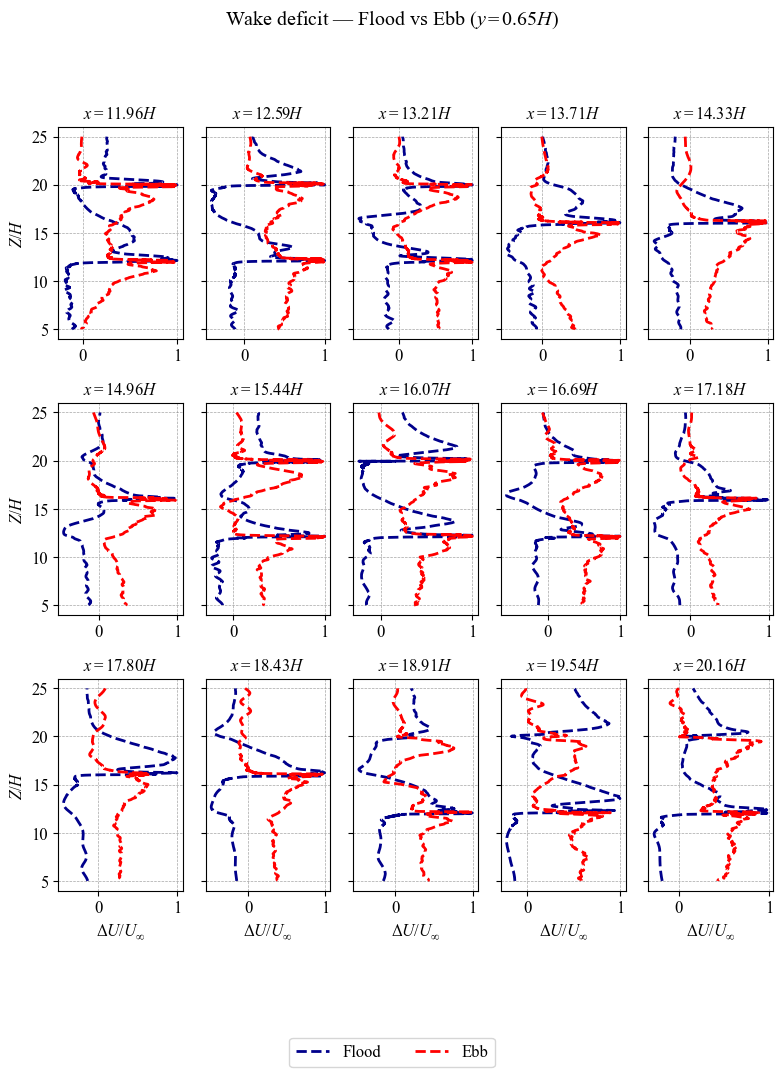

In [94]:
# Run the streamwise-speed cell above first (defines plot_flood_ebb_panels).
assert line_dfs_flood and line_dfs_ebb, 'Run section 7 extraction first.'

plot_flood_ebb_panels(
    line_dfs_flood,
    line_dfs_ebb,
    value_col='wake_deficit',
    xlabel=r'$\Delta U/U_{\infty}$',
    suptitle=f'Wake deficit — Flood vs Ebb ($y={TARGET_Y}H$)',
)